# H1 — Génération de mélodies par programmation par contraintes

**Auteurs** : *(à compléter)*
**Cours** : Programmation par Contraintes — EPITA SCIA 2026

---

Dans ce notebook, on génère des mélodies qui respectent les règles de base de la musique tonale, en utilisant **OR-Tools CP-SAT**. Le code est dans le package `melody/` à côté de ce notebook : ici, on l'utilise et on explique chaque étape.

## Plan

1. Le problème en CSP — variables, domaines, contraintes
2. Un peu de théorie musicale (le strict minimum)
3. Premier modèle : hard constraints seules
4. Soft constraints et profils stylistiques
5. Démo : génération et écoute

## 1. Le problème en CSP

On veut générer une suite de $n$ notes. Pour chaque note, on doit choisir une **hauteur**. Une mélodie est valide si elle respecte un ensemble de règles musicales (rester dans la gamme, ne pas faire de sauts trop grands, finir sur la tonique, etc.).

C'est exactement un **CSP** (cf. notebook CSP-1 du cours) :

- **Variables** $X = \{p_0, p_1, \dots, p_{n-1}\}$ — une variable entière par position de note.
- **Domaines** $D_t$ — l'ensemble des hauteurs MIDI possibles pour $p_t$ (par défaut, toutes les notes de la gamme entre Sol3 et Sol5).
- **Contraintes** $C$ — les règles musicales.

### Pourquoi CSP plutôt qu'autre chose ?

On aurait pu :
- générer aléatoirement et filtrer → trop d'échecs, l'espace est gigantesque
- utiliser un modèle génératif (RNN, transformer) → pas de garantie sur les règles

**Un solveur CP garantit que toute mélodie produite respecte les règles**. C'est la propriété fondamentale qu'on met en avant.

### Taille de l'espace

Calculons concrètement combien de mélodies sont *a priori* possibles, et combien restent après chaque contrainte. C'est pédagogiquement très parlant.

In [4]:
import math

import sys
import os

sys.path.insert(0, os.path.abspath('..'))

n = 16              # longueur de la melodie
tessitura = 25      # nombre de hauteurs MIDI dans la plage Sol3 -> Sol5
in_scale = 15       # parmi ces 25, environ 15 sont dans la gamme de Do majeur

print(f'Sans contrainte         : {tessitura**n:e} melodies possibles')
print(f'Avec contrainte gamme   : {in_scale**n:e}')
# Sauts <=7 demi-tons reduit grossierement le domaine moyen a ~8 voisins en gamme
print(f'Avec contrainte intervalle (approx) : {in_scale * 8**(n-1):e}')
# Avec premiere et derniere fixees : on enleve l'equivalent d'un facteur 15 a chaque bout
print(f'Avec debut/fin fixes    : {1 * 8**(n-1) * (1/3):e}  # tres approx')


Sans contrainte         : 2.328306e+22 melodies possibles
Avec contrainte gamme   : 6.568408e+18
Avec contrainte intervalle (approx) : 5.277656e+14
Avec debut/fin fixes    : 1.172812e+13  # tres approx


On passe d'environ $10^{22}$ mélodies possibles à $10^{13}$ après application des contraintes les plus structurantes — soit un facteur de réduction d'environ $10^9$. C'est ce qui rend le problème tractable.

Le solveur CP-SAT exploite ces réductions par **propagation** : dès qu'on fixe une note, il élimine automatiquement les valeurs des autres variables qui deviennent impossibles.

## 2. Théorie musicale — le minimum

Trois concepts suffisent pour comprendre le projet.

### Hauteurs MIDI

MIDI numérote chaque note de 0 à 127. **Do central = 60**. Chaque +1 = un demi-ton. Une octave = 12 demi-tons.

On définit le **pitch class** d'une note comme `pitch % 12` : 0 pour tous les Do, 7 pour tous les Sol, etc.

### Gamme

Une gamme est un sous-ensemble de 7 pitch classes sur les 12 possibles. En Do majeur : `{0, 2, 4, 5, 7, 9, 11}` = Do, Ré, Mi, Fa, Sol, La, Si.

**Toute note de la mélodie doit appartenir à la gamme**. C'est notre contrainte la plus importante.

### Degrés et cadence finale

Dans une gamme, chaque note a un rôle :

| Degré | Rôle |
|---|---|
| I (tonique) | stable, conclusif |
| V (dominante) | tendu, appelle la tonique |
| VII (sensible) | sous la tonique, veut y monter |

Une mélodie qui *sonne finie* termine par **V → I** ou **VII → I**. C'est ce qu'on appelle une **cadence**. On ajoutera donc une contrainte sur les deux dernières notes.

In [5]:
# Voyons ce que contient music_theory.py
from melody.music_theory import SCALES, scale_pitches, midi_to_name

print('Gammes disponibles :', list(SCALES.keys()))
print()
print('Tonique de Do majeur :', SCALES['C_major']['tonic'])
print('Pitch classes de Do majeur :', SCALES['C_major']['pcs'])
print()
# Quelques exemples de noms MIDI
for p in [60, 67, 72]:
    print(f'MIDI {p} = {midi_to_name(p)}')
print()
# Le domaine d'une variable pitch = hauteurs de la gamme dans la tessiture
domain = scale_pitches('C_major')
print(f'Domaine en Do majeur (Sol3-Sol5) : {len(domain)} hauteurs')
print(' '.join(midi_to_name(p) for p in domain))


Gammes disponibles : ['C_major', 'G_major', 'A_minor']

Tonique de Do majeur : 0
Pitch classes de Do majeur : [0, 2, 4, 5, 7, 9, 11]

MIDI 60 = C4
MIDI 67 = G4
MIDI 72 = C5

Domaine en Do majeur (Sol3-Sol5) : 15 hauteurs
G3 A3 B3 C4 D4 E4 F4 G4 A4 B4 C5 D5 E5 F5 G5


## 3. Premier modèle : hard constraints seules

On commence par le modèle minimal. Hard constraints uniquement, pas d'optimisation. Le solveur trouve **n'importe quelle** mélodie valide.

### Les hard constraints implémentées

Toutes dans `melody/solver.py`, fonction `build_model()`.

| # | Contrainte | Formulation CP |
|---|---|---|
| C1 | Première note = tonique | `pitch[0] % 12 == 0` (en Do majeur) |
| C2 | Dernière note = tonique | `pitch[-1] % 12 == 0` |
| C3 | Avant-dernière = V ou VII | `pitch[-2] % 12 ∈ {7, 11}` (cadence) |
| C4 | Sauts ≤ une quinte | `abs(pitch[t+1] - pitch[t]) <= 7` |
| C5 | Pas deux notes identiques consécutives | `abs(pitch[t+1] - pitch[t]) >= 1` |

C1, C2, C3 sont encodées avec `AddAllowedAssignments` (cf. CSP-1 §6).
C4 et C5 utilisent `AddAbsEquality`, présentée dans CSP-5.

Le domaine de chaque variable est déjà restreint à la gamme — on évite ainsi de poser la contrainte `pitch % 12 in scale` explicitement, ce qui rend le solveur beaucoup plus rapide.

In [6]:
from melody.solver import build_model
from ortools.sat.python import cp_model

# On construit le modele avec hard constraints uniquement
model, pitch = build_model(n_notes=12, scale_name='C_major')

# On lance le solveur SANS objectif : il prend la premiere solution valide trouvee
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 5.0
status = solver.Solve(model)

if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    raw_melody = [solver.Value(p) for p in pitch]
    from melody.export import to_text
    print('Melodie sans soft constraints :')
    print(to_text(raw_melody))
else:
    print('Pas de solution.')


Melodie sans soft constraints :
C4 A3 B3 C4 B3 C4 B3 C4 B3 C4 B3 C4


Cette mélodie respecte toutes les hard constraints, mais elle est probablement laide : elle peut osciller bêtement, rester sur 2-3 notes, etc. C'est ce qu'on attend d'un solveur qui n'a aucune préférence : il prend **la première solution qu'il trouve**.

Pour obtenir de la **musique**, il nous faut des **préférences**. C'est le rôle des soft constraints.

## 4. Soft constraints et profils stylistiques

Une **soft constraint** est une préférence : on ne l'impose pas, mais on paye un coût si elle est violée. Le solveur cherche alors une solution qui **minimise** la somme des coûts.

C'est exactement le **Weighted CSP** du notebook CSP-7. Formellement, on a :

$$\min \sum_i w_i \cdot \text{violation}_i$$

où $w_i$ est le poids de la $i$-ème préférence.

### Les 4 soft constraints implémentées

Toutes dans `melody/solver.py`.

1. **`smoothness`** — pénalise les sauts > 2 demi-tons. Cost = `max(0, |intervalle| - 2) × weight`.
2. **`range`** — pénalise un ambitus trop petit (< 1 octave). Cost = `max(0, 12 - ambitus) × weight`.
3. **`direction`** — pénalise les directions répétées (monter, monter, monter…). Cost = `weight` par continuité.
4. **`no_oscillation`** — pénalise les motifs A-B-A (`pitch[t+2] == pitch[t]`). Évite les oscillations triviales.

### Les 3 profils stylistiques

Chaque profil est une combinaison de poids :

| Profil | smoothness | range | direction | no_oscillation | Effet attendu |
|---|---|---|---|---|---|
| **fluide** | 5 | 1 | 1 | 3 | Mouvements conjoints, ligne fluide |
| **aventureux** | 1 | 5 | 3 | 2 | Sauts autorisés, large ambitus |
| **minimaliste** | 3 | 0 | 0 | 1 | Stable, monotone, sobre |

**C'est ici que se joue le côté "musical" du projet.** En changeant uniquement les coefficients, on obtient des styles différents. C'est la démonstration scientifique principale : *les soft constraints permettent de paramétrer le style sans changer le modèle*.

In [7]:
from melody import solve, to_text, PROFILES

print('Comparaison des 3 profils sur 16 notes en Do majeur :')
print('=' * 60)
for profile in PROFILES:
    m = solve(n_notes=16, scale_name='C_major', profile=profile, random_seed=42)
    print(f'\n[{profile:12s}] {to_text(m)}')
    # Calcul rapide de quelques stats
    intervals = [abs(m[t+1] - m[t]) for t in range(len(m)-1)]
    print(f'              ambitus = {max(m) - min(m)} demi-tons, '
          f'saut moyen = {sum(intervals)/len(intervals):.1f}')


Comparaison des 3 profils sur 16 notes en Do majeur :

[fluide      ] C4 D4 C4 B3 A3 G3 A3 B3 C4 D4 E4 F4 G4 A4 B4 C5
              ambitus = 17 demi-tons, saut moyen = 1.7

[aventureux  ] C5 D5 B4 C5 A4 B4 G4 A4 F4 G4 E4 F4 C4 D4 B3 C4
              ambitus = 15 demi-tons, saut moyen = 2.5

[minimaliste ] C4 D4 E4 F4 G4 A4 B4 C5 D5 C5 B4 A4 G4 A4 B4 C5
              ambitus = 14 demi-tons, saut moyen = 1.7


## 5. Démo : visualisation et écoute

On génère plusieurs mélodies différentes, on les affiche en **piano roll** et on exporte des fichiers MIDI écoutables.

### Astuce technique : éviter les solutions identiques

Quand on relance le solveur avec les mêmes paramètres, il a tendance à retomber sur la même solution (la première mélodie optimale trouvée). Pour obtenir de la diversité, on utilise `solve_many()` qui ajoute après chaque solution une contrainte interdisant cette mélodie exacte. Le solveur est alors forcé d'en chercher une autre.

```python
# Pour chaque melodie deja generee, on ajoute :
#   au moins une note doit differer
model.AddBoolOr([pitch[t] != prev[t] for t in range(n)])
```

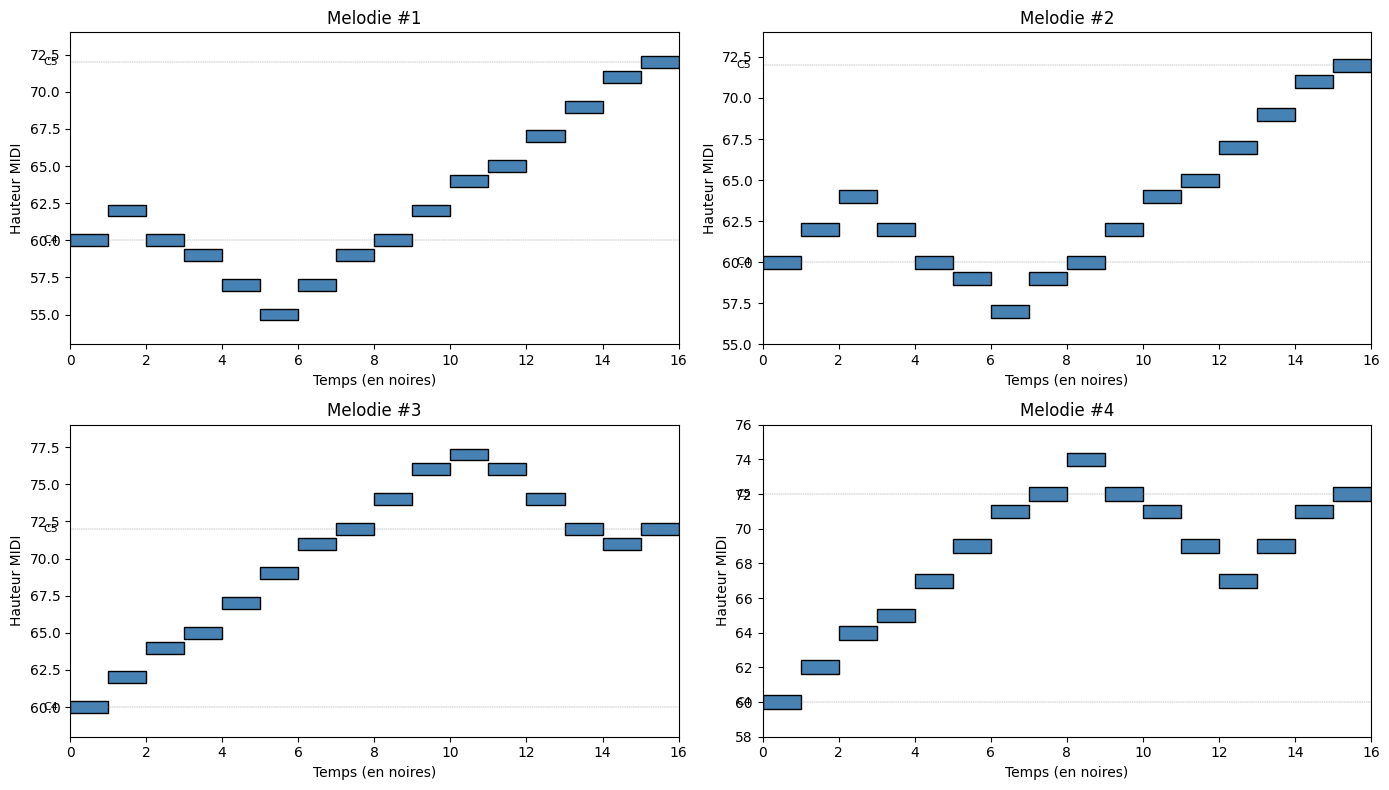

In [8]:
import matplotlib.pyplot as plt
from melody import solve_many, plot_piano_roll, to_midi

# 4 melodies fluides differentes
melodies = solve_many(n=4, n_notes=16, scale_name='C_major', profile='fluide', time_limit=3.0)

# Affichage en grille 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (m, ax) in enumerate(zip(melodies, axes.flat)):
    plot_piano_roll(m, title=f'Melodie #{i+1}', ax=ax)
plt.tight_layout()
plt.show()


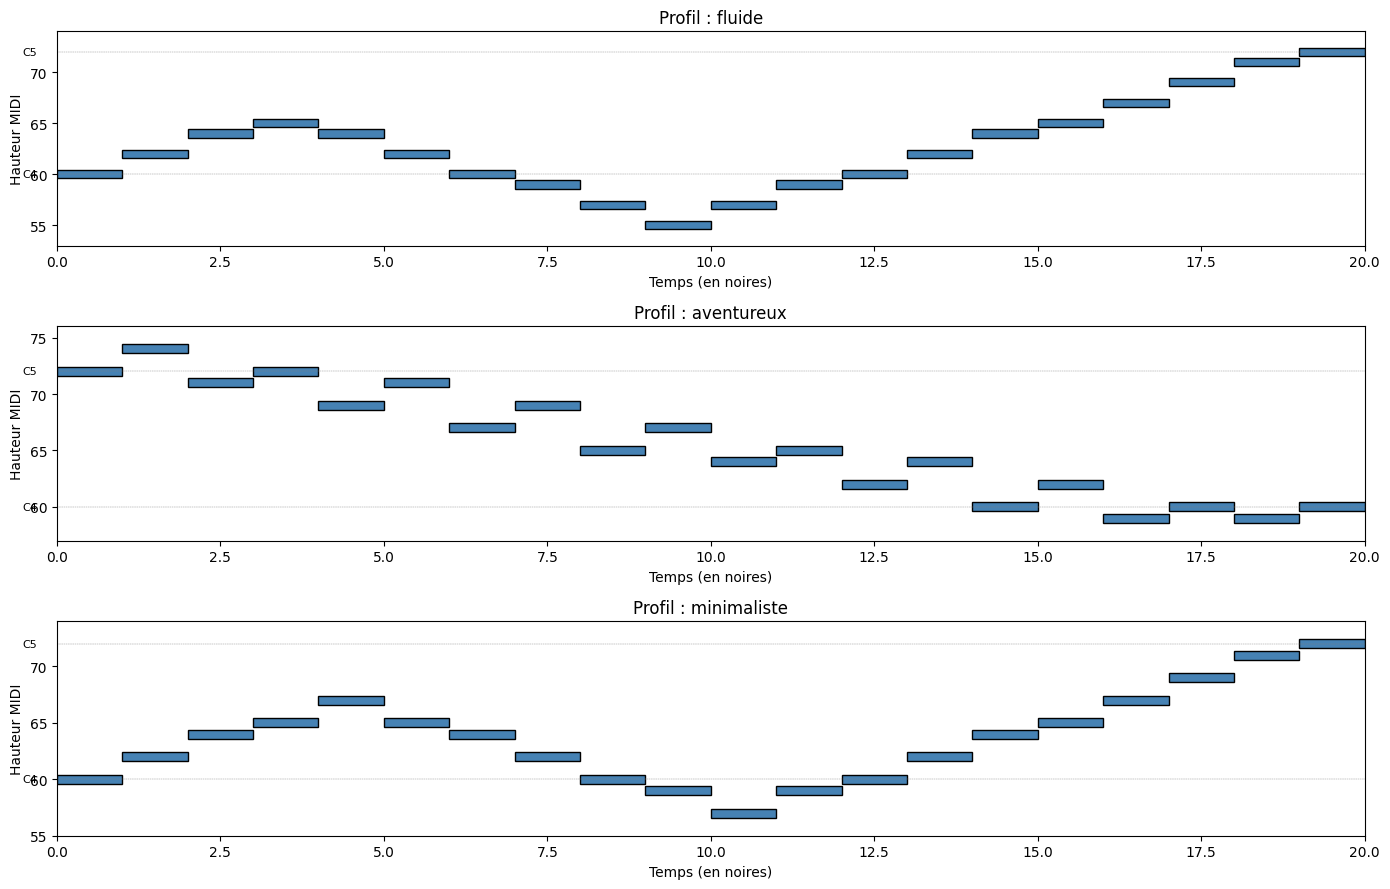

In [9]:
# Comparaison des 3 profils sur la meme longueur
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, profile in zip(axes, PROFILES):
    m = solve(n_notes=20, scale_name='C_major', profile=profile, random_seed=11)
    plot_piano_roll(m, title=f'Profil : {profile}', ax=ax)
plt.tight_layout()
plt.show()


In [10]:
# Export MIDI pour ecoute
import os
os.makedirs('outputs', exist_ok=True)

for profile in PROFILES:
    m = solve(n_notes=24, scale_name='C_major', profile=profile, random_seed=7)
    path = f'outputs/demo_{profile}.mid'
    to_midi(m, path, tempo=110)
    print(f'Genere : {path}')
print()
print('Ces fichiers s\'ouvrent avec VLC, MuseScore, ou sur https://onlinesequencer.net/import')


Genere : outputs/demo_fluide.mid
Genere : outputs/demo_aventureux.mid
Genere : outputs/demo_minimaliste.mid

Ces fichiers s'ouvrent avec VLC, MuseScore, ou sur https://onlinesequencer.net/import


## 6. Vérification : nos contraintes sont-elles bien respectées ?

Petite sanity check pour la soutenance : on vérifie *a posteriori* que les mélodies générées respectent bien toutes les hard constraints. Ce n'est pas indispensable (le solveur le garantit), mais c'est rassurant et démonstratif.

In [11]:
from melody.music_theory import SCALES

def check_melody(melody, scale_name='C_major'):
    """Verifie que la melodie respecte les 5 hard constraints."""
    pcs = SCALES[scale_name]['pcs']
    tonic = SCALES[scale_name]['tonic']
    
    checks = {
        'toutes les notes dans la gamme' : all(p % 12 in pcs for p in melody),
        'premiere note = tonique'        : melody[0] % 12 == tonic,
        'derniere note = tonique'        : melody[-1] % 12 == tonic,
        'avant-derniere = V ou VII'      : melody[-2] % 12 in [pcs[4], pcs[6]],
        'sauts <= 7 demi-tons'           : all(abs(melody[t+1]-melody[t]) <= 7 for t in range(len(melody)-1)),
        'pas deux notes identiques cons.': all(melody[t] != melody[t+1] for t in range(len(melody)-1)),
    }
    return checks

m = solve(n_notes=16, profile='fluide', random_seed=3)
print('Melodie :', to_text(m))
print()
for rule, ok in check_melody(m).items():
    status = '[OK]' if ok else '[ECHEC]'
    print(f'  {status} {rule}')


Melodie : C4 D4 E4 F4 G4 A4 G4 F4 E4 D4 E4 F4 G4 A4 B4 C5

  [OK] toutes les notes dans la gamme
  [OK] premiere note = tonique
  [OK] derniere note = tonique
  [OK] avant-derniere = V ou VII
  [OK] sauts <= 7 demi-tons
  [OK] pas deux notes identiques cons.


## 7. Conclusion

Ce qu'on a montré :

- La composition musicale **se modélise très naturellement en CSP** : variables = notes, domaines = hauteurs, contraintes = règles.
- Les **hard constraints** (gamme, intervalles, cadence) garantissent la validité musicale.
- Les **soft constraints** (Weighted CSP, notebook CSP-7) permettent de paramétrer le **style** sans changer le modèle.
- En **changeant uniquement les poids**, on obtient trois styles distincts et reconnaissables.

Ce qu'on n'a pas fait (assumé) :

- **Pas de polyphonie** — on se concentre sur les hauteurs d'une seule voix, sans contrepoint à plusieurs voix.
- **Pas de rythme** — toutes les notes durent une noire. Ajouter le rythme demanderait des variables `duration[t]` et des contraintes métriques.
- **Pas d'évaluation humaine** — on ne juge pas si c'est "beau", on vérifie objectivement que les règles sont respectées et on laisse le jury écouter.

Pour aller plus loin :

- Ajouter une 2e voix (basse) avec contraintes de consonance → on entre dans le **contrepoint**.
- Ajouter des durées variables → contraintes métriques (somme des durées = nombre de mesures).
- **Mode variation** : on fixe certaines notes (`model.Add(pitch[t] == valeur)`) et on laisse le solveur compléter.